In [1]:
import pandas as pd
import tensorflow as tf
import numpy as np
import gc
import time
#import matplotlib.pyplot as plt
#from livelossplot.keras import PlotLossesCallback
from tensorflow.keras.callbacks import ReduceLROnPlateau
#from keras.models import load_model
import csv
from itertools import chain
from matplotlib import pyplot as plt

D:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
D:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
D:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\tensorflow\python\framework\dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
D:\ProgramData\Anaconda3\envs\tensorflow210\lib\s

### 设置GPU显存按需分配

In [2]:
#如果没有装GPU版本，这部分就不用写，但是如果不用GPU加速计算，使用CPU将会严重限制模型的训练速度
gpus = tf.config.experimental.list_physical_devices('GPU') 
if gpus:
  try:

    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    logical_gpus = tf.config.experimental.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:

    print(e)

1 Physical GPUs, 1 Logical GPUs


### 载入数据

In [3]:
data_train=pd.read_csv('F:/TensorFlow/traindata20231111.csv',header=0,encoding='utf_8')
data_train.info()
data_train.ClassName.unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10315 entries, 0 to 10314
Columns: 247 entries, FID to SR221024B7
dtypes: float64(7), int64(235), object(5)
memory usage: 19.4+ MB


array(['耕地', '森林', '大棚', '撂荒地', '城市绿地', '沼泽', '裸地', '灌丛', '草地', '荒漠',
       '水体'], dtype=object)

In [4]:
pd.set_option('display.max_rows', None)
print(data_train['ClassName'].value_counts())

耕地      6879
森林      1429
草地       987
荒漠       538
大棚       355
撂荒地       41
灌丛        37
沼泽        26
裸地        13
城市绿地       9
水体         1
Name: ClassName, dtype: int64


In [5]:
data_train.head()

,FID,编号,经度CGCS,纬度CGCS,一级类,二级类,ClassName,大棚_地,num,AET2201,...,SR220930B5,SR220930B6,SR220930B7,SR221024B1,SR221024B2,SR221024B3,SR221024B4,SR221024B5,SR221024B6,SR221024B7
0,0,LC-01-0718-71,115.479510,35.852367,耕地,水浇地,耕地,,0,81,...,1863,1648,1183,1107,1835,728,1001,1868,1719,1287
1,1,LC-01-0718-72,115.455465,35.841351,耕地,水浇地,耕地,,0,80,...,1532,1115,718,857,1758,510,794,1796,1566,1059
2,2,LC-01-0718-73,115.445464,35.816896,耕地,水浇地,耕地,,0,86,...,1863,1648,1183,1107,1835,728,1001,1868,1719,1287
3,3,LC-01-0718-74,115.440885,35.793716,耕地,水浇地,耕地,,0,86,...,1303,1037,571,857,1758,510,794,1796,1566,1059
4,4,LC-01-0718-75,115.437554,35.777476,耕地,水浇地,耕地,,0,84,...,1982,1690,1260,1072,1981,587,915,2083,2013,1575


In [6]:
# 生成该区间的随意唯一索引
index = np.random.permutation(len(data_train))
# 用生成的乱的索引就能将其打乱了
data_all = data_train.iloc[index ,:]

### 切分数据

In [39]:
split_index = int(len(data_all)*0.7)
data_train = data_all.iloc[:split_index]

data_test = data_all.iloc[split_index:]
data_test.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3095 entries, 24 to 9806
Columns: 247 entries, FID to SR221024B7
dtypes: float64(7), int64(235), object(5)
memory usage: 5.9+ MB


In [40]:
train_x = data_train.iloc[:,9:]
train_y = data_train.loc[:, ['num']] 

test_x = data_test.iloc[:,9:]
test_y = data_test.loc[:, ['num']] 
train_x.head(), train_y.head()

(       AET2201  AET2202  AET2203  AET2204  AET2205  AET2206  AET2207  AET2208  \
 10142        0        0       73       52      135      291      531      621   
 5558         0        0       55       52       87      214      349      413   
 6011         0        0      132      155      411      253     1394     1224   
 6071         0        0       45       47       87      186      341      495   
 5008         0        0       87      136      132      148      363      513   
 
        AET2209  AET2210  ...  SR220930B5  SR220930B6  SR220930B7  SR221024B1  \
 10142      346       59  ...        3380        3619        3120        2110   
 5558        79       45  ...        2066        1701        1083         702   
 6011       408      316  ...        2362        2067        1097         657   
 6071       161       30  ...        2518        2281        1470        1029   
 5008        39       92  ...        2543        2209        1513        1257   
 
        SR221024B2

### 类别数量

In [7]:
num_classes = data_train['ClassName'].nunique()
print(num_classes)

11


### 不测试时使用全部数据训练

In [8]:
train_x = data_train.iloc[:,9:]
train_y = data_train.loc[:, ['num']] 

In [9]:
train_x.head()

,AET2201,AET2202,AET2203,AET2204,AET2205,AET2206,AET2207,AET2208,AET2209,AET2210,...,SR220930B5,SR220930B6,SR220930B7,SR221024B1,SR221024B2,SR221024B3,SR221024B4,SR221024B5,SR221024B6,SR221024B7
0,81,203,355,189,143,516,1359,778,236,674,...,1863,1648,1183,1107,1835,728,1001,1868,1719,1287
1,80,200,339,183,144,506,1363,752,235,657,...,1532,1115,718,857,1758,510,794,1796,1566,1059
2,86,184,322,178,139,496,1364,749,229,652,...,1863,1648,1183,1107,1835,728,1001,1868,1719,1287
3,86,184,322,178,139,496,1364,749,229,652,...,1303,1037,571,857,1758,510,794,1796,1566,1059
4,84,177,321,173,137,493,1362,749,226,656,...,1982,1690,1260,1072,1981,587,915,2083,2013,1575


### 顺序编码转独热编码

In [10]:
train_y = tf.keras.utils.to_categorical(train_y)

In [11]:
train_x.head()
train_y

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.]], dtype=float32)

### 定义损失函数为Focal Loss

In [12]:
def multi_category_focal_loss2(gamma=2., alpha=.25):
    """
    focal loss for multi category of multi label problem
    适用于多分类或多标签问题的focal loss
    alpha控制真值y_true为1/0时的权重
        1的权重为alpha, 0的权重为1-alpha
    当你的模型欠拟合，学习存在困难时，可以尝试适用本函数作为loss
    当模型过于激进(无论何时总是倾向于预测出1),尝试将alpha调小
    当模型过于惰性(无论何时总是倾向于预测出0,或是某一个固定的常数,说明没有学到有效特征)
        尝试将alpha调大,鼓励模型进行预测出1。
    Usage:
     model.compile(loss=[multi_category_focal_loss2(alpha=0.25, gamma=2)], metrics=["accuracy"], optimizer='adam')
    """
    epsilon = 1.e-7
    gamma = float(gamma)
    alpha = tf.constant(alpha, dtype=tf.float32)

    def multi_category_focal_loss2_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
    
        alpha_t = y_true*alpha + (tf.ones_like(y_true)-y_true)*(1-alpha)
        y_t = tf.multiply(y_true, y_pred) + tf.multiply(1-y_true, 1-y_pred)
        y_t = tf.clip_by_value(y_t, epsilon, 1. - epsilon)#这句是后加的
        ce = -tf.math.log(y_t)
        weight = tf.math.pow(tf.subtract(1., y_t), gamma)
        fl = tf.multiply(tf.multiply(weight, ce), alpha_t)
        loss = tf.reduce_mean(fl)
        return loss
    return multi_category_focal_loss2_fixed

### 模型构建

In [13]:
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(4096,input_dim=238))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(2048,activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(1024,activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(512,activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(256,activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(128,activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(64,activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(32,activation='relu'))#注：如果后面再加16，8，16，32这样的全连结层，精度反而会变低
model.add(tf.keras.layers.Dropout(rate=0.5))
model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))#不懂为啥有时候对不上非要+1
# 让学习率自动变化
reduce_lr = ReduceLROnPlateau(monitor='loss',factor=0.1, patience=20, mode='auto')
model.compile(loss='categorical_crossentropy', metrics=['acc'], optimizer='adam')#adam优化
#顺序编码用loss='sparse_categorical_crossentropy'
#独热编码用loss='categorical_crossentropy'
tf.random.set_random_seed(1024)
model.summary()

Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 4096)              978944    
_________________________________________________________________
batch_normalization (BatchNo (None, 4096)              16384     
_________________________________________________________________
dense_1 (Dense)              (None, 2048)              8390656   
_________________________________________________________________
batch_normalization_1 (Batch (None, 2048)              8192      
_________________________________________________________________
dense_2 (Dense)              (None, 1024)              2098176   
_________________________________________________________________
batch_normalization_2 (Batch (None, 1024)              4096      
___

### 开始训练

In [14]:
e = 200
start = time.perf_counter()#time.process_time()测的时间偏长
history = model.fit(train_x,train_y, epochs=e,batch_size=32,verbose=1,callbacks=[reduce_lr])#batch_size=16,validation_data=(validation_x,validation_y)
mins, secs = divmod((time.perf_counter() - start), 60)
hours, mins = divmod(mins, 60)
print("用时：%02d:%02d:%02d"% (hours, mins, secs))

Epoch 1/200
10315/10315 [==============================] - 4s 411us/sample - loss: 1.2535 - acc: 0.6079
Epoch 2/200
10315/10315 [==============================] - 3s 286us/sample - loss: 0.9422 - acc: 0.7025
Epoch 3/200
10315/10315 [==============================] - 3s 285us/sample - loss: 0.8526 - acc: 0.7200
Epoch 4/200
10315/10315 [==============================] - 3s 299us/sample - loss: 0.8233 - acc: 0.7348
Epoch 5/200
10315/10315 [==============================] - 3s 307us/sample - loss: 0.7981 - acc: 0.7333
Epoch 6/200
10315/10315 [==============================] - 3s 295us/sample - loss: 0.7772 - acc: 0.7371
Epoch 7/200
10315/10315 [==============================] - 3s 291us/sample - loss: 0.7768 - acc: 0.7379
Epoch 8/200
10315/10315 [==============================] - 3s 291us/sample - loss: 0.7718 - acc: 0.7424
Epoch 9/200
10315/10315 [==============================] - 3s 300us/sample - loss: 0.7559 - acc: 0.7448
Epoch 10/200
10315/10315 [==============================] - 3s 2

10315/10315 [==============================] - 3s 285us/sample - loss: 0.3522 - acc: 0.8749
Epoch 80/200
10315/10315 [==============================] - 3s 288us/sample - loss: 0.3566 - acc: 0.8719
Epoch 81/200
10315/10315 [==============================] - 3s 289us/sample - loss: 0.3521 - acc: 0.8767
Epoch 82/200
10315/10315 [==============================] - 3s 288us/sample - loss: 0.3326 - acc: 0.8819
Epoch 83/200
10315/10315 [==============================] - 3s 294us/sample - loss: 0.3289 - acc: 0.8818
Epoch 84/200
10315/10315 [==============================] - 3s 293us/sample - loss: 0.3348 - acc: 0.8823
Epoch 85/200
10315/10315 [==============================] - 3s 298us/sample - loss: 0.3375 - acc: 0.8807
Epoch 86/200
10315/10315 [==============================] - 3s 286us/sample - loss: 0.3371 - acc: 0.8827
Epoch 87/200
10315/10315 [==============================] - 3s 286us/sample - loss: 0.3320 - acc: 0.8822
Epoch 88/200
10315/10315 [==============================] - 3s 287us

10315/10315 [==============================] - 3s 301us/sample - loss: 0.2023 - acc: 0.9308
Epoch 157/200
10315/10315 [==============================] - 3s 304us/sample - loss: 0.1750 - acc: 0.9391
Epoch 158/200
10315/10315 [==============================] - 3s 302us/sample - loss: 0.1620 - acc: 0.9465
Epoch 159/200
10315/10315 [==============================] - 3s 314us/sample - loss: 0.1638 - acc: 0.9459
Epoch 160/200
10315/10315 [==============================] - 3s 290us/sample - loss: 0.1543 - acc: 0.9472
Epoch 161/200
10315/10315 [==============================] - 3s 291us/sample - loss: 0.2114 - acc: 0.9297
Epoch 162/200
10315/10315 [==============================] - 3s 292us/sample - loss: 0.1807 - acc: 0.9374
Epoch 163/200
10315/10315 [==============================] - 3s 293us/sample - loss: 0.1940 - acc: 0.9348
Epoch 164/200
10315/10315 [==============================] - 3s 293us/sample - loss: 0.1579 - acc: 0.9466
Epoch 165/200
10315/10315 [==============================] -

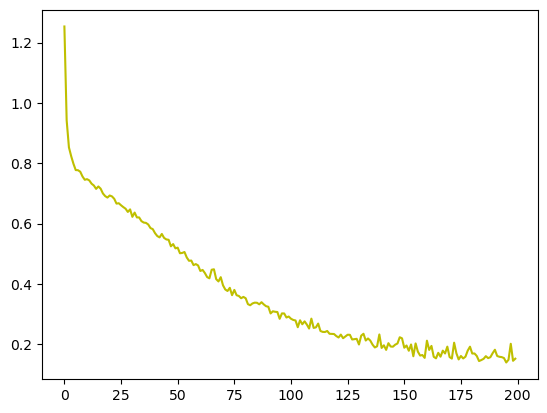

In [16]:
plt.plot(range(200),history.history.get('loss'),color =  'y')

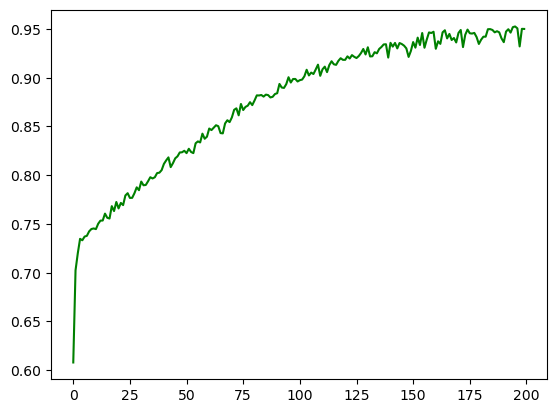

In [17]:
plt.plot(range(200),history.history.get('acc'),color =  'g')

In [18]:
model.save(r'F:/TensorFlow/model_data/model_YR_202311112.h5')

### 计算准确率

In [49]:
test_r = pd.DataFrame(model.predict_classes(test_x,verbose=1))
test_r = test_r.values
acc_array = (test_y == test_r)
print('准确率：', np.sum(acc_array!=0)/len(acc_array))

3095/3095 [==============================] - 1s 167us/sample
准确率： num    0.769952
dtype: float64


### 各类别准确率

In [19]:
test_y = list(chain.from_iterable(test_y))
test_r = list(chain.from_iterable(test_r))

def count_nums(true_labels, num_classes):
    initial_value = 0
    list_length = num_classes
    list_data = [ initial_value for i in range(list_length)]
    for i in range(0, num_classes):
        list_data[i] = true_labels.count(i)
    return list_data

def accuracy(confusion_matrix, true_labels, num_classes):
    # 各个类别的测试样本的个数
    list_data = count_nums(true_labels, num_classes)
 
    # 各个类别正确分类的个数
    initial_value = 0
    list_length = num_classes
    true_pred = [ initial_value for i in range(list_length)]
    for i in range(0,num_classes):
        true_pred[i] = confusion_matrix[i][i]
 
    # 计算各个样本被正确分类的正确率
    classveg = []
    acc = []
    for i in range(0, num_classes):
        classveg.append(0)
        acc.append(0)
 
    for i in range(0,num_classes):
        classveg[i] = i
        acc[i] = float(true_pred[i] / list_data[i])
    
    z = pd.DataFrame(list(zip(classveg,acc,list_data)), columns=['class_code', 'acc','count'])
    return z

op = tf.math.confusion_matrix(test_y, test_r)

acc = accuracy(op, test_y, num_classes)
print(acc)

NameError: name 'test_y' is not defined

### 出结果

In [23]:
gc.collect()
def predict(file):
    #mylist = []
    index=0
    for chunk in pd.read_csv(file, chunksize=100000):
        print(index)
        rchunk = pd.DataFrame(model.predict_classes(chunk,verbose=1))
        #mylist.append(rchunk)
        arry1 = np.array(rchunk) #先转成np数据
        list1 = arry1.tolist()  #再转成list
        with open('F:/TensorFlow/testresult20231112_p1.csv','a',newline='',encoding='utf-8') as f:
          writer = csv.writer(f)
          writer.writerows(list1)
        index+=1
    #temp_df = pd.concat(mylist, axis= 0)
    #del mylist
    #return temp_df

start = time.perf_counter()
f = open('E:/all20131109/testdata20231109_p1.txt',encoding='utf-8')#p2 ,encoding='gb2312'
prediction = predict(f)
#np.savetxt("testresult20200523caoyuan.csv", prediction, fmt="%d",delimiter=",") 
mins, secs = divmod((time.perf_counter() - start), 60)
hours, mins = divmod(mins, 60)
print("用时：%02d:%02d:%02d"% (hours, mins, secs))

0
100000/100000 [==============================] - 4s 42us/sample
1
100000/100000 [==============================] - 4s 39us/sample
2
100000/100000 [==============================] - 4s 40us/sample
3
100000/100000 [==============================] - 4s 39us/sample
4
100000/100000 [==============================] - 4s 40us/sample
5
100000/100000 [==============================] - 4s 38us/sample
6
100000/100000 [==============================] - 4s 40us/sample
7
100000/100000 [==============================] - 4s 39us/sample
8
100000/100000 [==============================] - 4s 39us/sample
9
100000/100000 [==============================] - 4s 39us/sample
10
100000/100000 [==============================] - 4s 38us/sample
11
100000/100000 [==============================] - 4s 39us/sample
12
100000/100000 [==============================] - 4s 39us/sample
13
100000/100000 [==============================] - 4s 39us/sample
14
100000/100000 [==============================] - 4s 39us/sample
15
10

In [24]:
gc.collect()
def predict(file):
    #mylist = []
    index=0
    for chunk in pd.read_csv(file, chunksize=100000):
        print(index)
        rchunk = pd.DataFrame(model.predict_classes(chunk,verbose=1))
        #mylist.append(rchunk)
        arry1 = np.array(rchunk) #先转成np数据
        list1 = arry1.tolist()  #再转成list
        with open('F:/TensorFlow/testresult20231112_p2.csv','a',newline='',encoding='utf-8') as f:
          writer = csv.writer(f)
          writer.writerows(list1)
        index+=1
    #temp_df = pd.concat(mylist, axis= 0)
    #del mylist
    #return temp_df

start = time.perf_counter()
f = open('E:/all20131109/testdata20231109_p2.txt',encoding='utf-8')#p2 ,encoding='gb2312'
prediction = predict(f)
#np.savetxt("testresult20200523caoyuan.csv", prediction, fmt="%d",delimiter=",") 
mins, secs = divmod((time.perf_counter() - start), 60)
hours, mins = divmod(mins, 60)
print("用时：%02d:%02d:%02d"% (hours, mins, secs))

0
100000/100000 [==============================] - 4s 38us/sample
1
100000/100000 [==============================] - 4s 39us/sample
2
100000/100000 [==============================] - 4s 39us/sample
3
100000/100000 [==============================] - 4s 39us/sample
4
100000/100000 [==============================] - 4s 39us/sample
5
100000/100000 [==============================] - 4s 40us/sample
6
100000/100000 [==============================] - 4s 39us/sample
7
100000/100000 [==============================] - 4s 39us/sample
8
100000/100000 [==============================] - 4s 40us/sample
9
100000/100000 [==============================] - 4s 39us/sample
10
100000/100000 [==============================] - 4s 39us/sample
11
100000/100000 [==============================] - 4s 39us/sample
12
100000/100000 [==============================] - 4s 39us/sample
13
100000/100000 [==============================] - 4s 41us/sample
14
100000/100000 [==============================] - 4s 41us/sample
15
10

In [25]:
gc.collect()
def predict(file):
    #mylist = []
    index=0
    for chunk in pd.read_csv(file, chunksize=100000):
        print(index)
        rchunk = pd.DataFrame(model.predict_classes(chunk,verbose=1))
        #mylist.append(rchunk)
        arry1 = np.array(rchunk) #先转成np数据
        list1 = arry1.tolist()  #再转成list
        with open('F:/TensorFlow/testresult20231112_p3.csv','a',newline='',encoding='utf-8') as f:
          writer = csv.writer(f)
          writer.writerows(list1)
        index+=1
    #temp_df = pd.concat(mylist, axis= 0)
    #del mylist
    #return temp_df

start = time.perf_counter()
f = open('E:/all20131109/testdata20231109_p3.txt',encoding='utf-8')#p2 ,encoding='gb2312'
prediction = predict(f)
#np.savetxt("testresult20200523caoyuan.csv", prediction, fmt="%d",delimiter=",") 
mins, secs = divmod((time.perf_counter() - start), 60)
hours, mins = divmod(mins, 60)
print("用时：%02d:%02d:%02d"% (hours, mins, secs))

0
100000/100000 [==============================] - 4s 40us/sample
1
100000/100000 [==============================] - 4s 39us/sample
2
100000/100000 [==============================] - 4s 40us/sample
3
100000/100000 [==============================] - 4s 39us/sample
4
100000/100000 [==============================] - 4s 40us/sample
5
100000/100000 [==============================] - 4s 39us/sample
6
100000/100000 [==============================] - 4s 38us/sample
7
100000/100000 [==============================] - 4s 39us/sample
8
100000/100000 [==============================] - 4s 39us/sample
9
100000/100000 [==============================] - 4s 39us/sample
10
100000/100000 [==============================] - 4s 38us/sample
11
100000/100000 [==============================] - 4s 39us/sample
12
100000/100000 [==============================] - 4s 39us/sample
13
100000/100000 [==============================] - 4s 40us/sample
14
100000/100000 [==============================] - 4s 39us/sample
15
10

In [26]:
gc.collect()
def predict(file):
    #mylist = []
    index=0
    for chunk in pd.read_csv(file, chunksize=100000):
        print(index)
        rchunk = pd.DataFrame(model.predict_classes(chunk,verbose=1))
        #mylist.append(rchunk)
        arry1 = np.array(rchunk) #先转成np数据
        list1 = arry1.tolist()  #再转成list
        with open('F:/TensorFlow/testresult20231112_p4.csv','a',newline='',encoding='utf-8') as f:
          writer = csv.writer(f)
          writer.writerows(list1)
        index+=1
    #temp_df = pd.concat(mylist, axis= 0)
    #del mylist
    #return temp_df

start = time.perf_counter()
f = open('E:/all20131109/testdata20231109_p4.txt',encoding='utf-8')#p2 ,encoding='gb2312'
prediction = predict(f)
#np.savetxt("testresult20200523caoyuan.csv", prediction, fmt="%d",delimiter=",") 
mins, secs = divmod((time.perf_counter() - start), 60)
hours, mins = divmod(mins, 60)
print("用时：%02d:%02d:%02d"% (hours, mins, secs))

0
100000/100000 [==============================] - 4s 39us/sample
1
100000/100000 [==============================] - 4s 39us/sample
2
100000/100000 [==============================] - 4s 39us/sample
3
100000/100000 [==============================] - 4s 39us/sample
4
100000/100000 [==============================] - 4s 39us/sample
5
100000/100000 [==============================] - 4s 39us/sample
6
100000/100000 [==============================] - 4s 38us/sample
7
100000/100000 [==============================] - 4s 39us/sample
8
100000/100000 [==============================] - 4s 38us/sample
9
100000/100000 [==============================] - 4s 39us/sample
10
100000/100000 [==============================] - 4s 40us/sample
11
100000/100000 [==============================] - 4s 39us/sample
12
100000/100000 [==============================] - 4s 40us/sample
13
100000/100000 [==============================] - 4s 39us/sample
14
100000/100000 [==============================] - 4s 39us/sample
15
10